In [1]:
import sys
print(sys.executable)


c:\Users\96277\anaconda3\envs\nicu-sepsis\python.exe


=== BEFORE (raw data) ===
Rows: total=8,335,615 | pos=22,254 | neg=8,313,361
Patients: total=923 | pos=146 | neg=777

=== AFTER (patient-level undersampling) ===
Rows: total=4,483,483 | pos=22,254 | neg=4,461,229
Patients: total=438 | pos=146 | neg=292

NEG_TO_POS_RATIO used: 2 (by patients)
Saved to: data\processed\undersampled_by_patient.csv


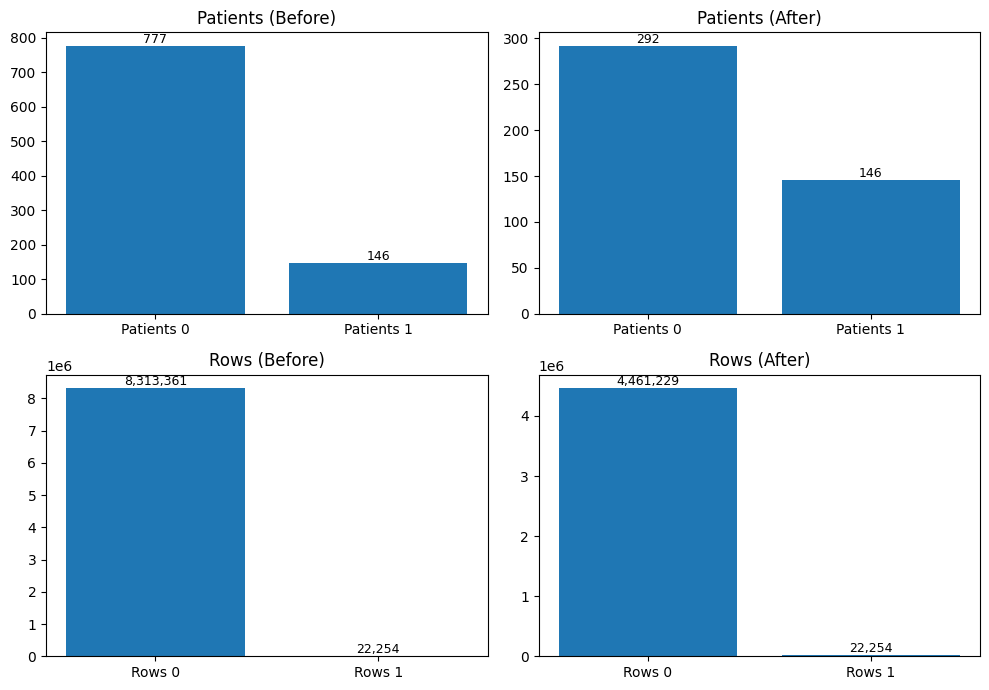

In [5]:
# STEP 1: Patient-level undersampling with full report & plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

DATA_PATH = r"C:\Users\96277\nicu-sepsis\data\raw\features.csv"  #"data/raw/features.csv"     
LABEL_COL = "sepsis_window"
ID_COL = "new_id"
NEG_TO_POS_RATIO = 2                     # كم مريض سليم نقابله لكل مريض مصاب
RANDOM_SEED = 42
OUT_DIR = Path("data/processed")
OUT_CSV = OUT_DIR / "undersampled_by_patient.csv"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

# --- تصنيف المرضى: مريض "إيجابي" إذا عنده أي صف label=1
patient_label = (
    df.groupby(ID_COL)[LABEL_COL]
      .max()  # إذا فيه أي 1 → المريض محسوب إيجابي
      .rename("patient_sepsis")
)

# دمج الملخص مع IDs
patient_label = patient_label.reset_index()

pos_ids = patient_label.loc[patient_label["patient_sepsis"] == 1, ID_COL].tolist()
neg_ids = patient_label.loc[patient_label["patient_sepsis"] == 0, ID_COL].tolist()

# --- تقرير قبل المعالجة
n_rows_total = len(df)
n_patients_total = patient_label.shape[0]
n_rows_pos = df[df[LABEL_COL] == 1].shape[0]
n_rows_neg = df[df[LABEL_COL] == 0].shape[0]

print("=== BEFORE (raw data) ===")
print(f"Rows: total={n_rows_total:,} | pos={n_rows_pos:,} | neg={n_rows_neg:,}")
print(f"Patients: total={n_patients_total:,} | pos={len(pos_ids):,} | neg={len(neg_ids):,}")

# --- اختيار عيّنة من المرضى السلبيين (undersample by patient)
k = NEG_TO_POS_RATIO
neg_keep = min(len(neg_ids), len(pos_ids) * k)
neg_ids_sample = random.sample(neg_ids, neg_keep)

final_patient_ids = set(pos_ids) | set(neg_ids_sample)

# --- فلترة كل الصفوف الخاصة بالمرضى المختارين
df_bal = df[df[ID_COL].isin(final_patient_ids)].copy()

# --- تقرير بعد المعالجة
patient_label_bal = (
    df_bal.groupby(ID_COL)[LABEL_COL]
          .max()
          .rename("patient_sepsis")
          .reset_index()
)
pos_ids_bal = patient_label_bal.loc[patient_label_bal["patient_sepsis"] == 1, ID_COL]
neg_ids_bal = patient_label_bal.loc[patient_label_bal["patient_sepsis"] == 0, ID_COL]

n_rows_total_bal = len(df_bal)
n_rows_pos_bal = df_bal[df_bal[LABEL_COL] == 1].shape[0]
n_rows_neg_bal = df_bal[df_bal[LABEL_COL] == 0].shape[0]

print("\n=== AFTER (patient-level undersampling) ===")
print(f"Rows: total={n_rows_total_bal:,} | pos={n_rows_pos_bal:,} | neg={n_rows_neg_bal:,}")
print(f"Patients: total={patient_label_bal.shape[0]:,} | pos={len(pos_ids_bal):,} | neg={len(neg_ids_bal):,}")
print(f"\nNEG_TO_POS_RATIO used: {k} (by patients)")
print(f"Saved to: {OUT_CSV}")

# --- حفظ النسخة المفلترة لاستخدامها لاحقاً
df_bal.to_csv(OUT_CSV, index=False)

# --- رسومات: توزيع قبل/بعد (على مستوى المرضى وعلى مستوى الصفوف)
def bar(ax, labels, values, title):
    ax.bar(labels, values)
    ax.set_title(title)
    for i, v in enumerate(values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

fig = plt.figure(figsize=(10, 7))

# قبل: مرضى
ax1 = plt.subplot(2, 2, 1)
bar(ax1,
    ["Patients 0", "Patients 1"],
    [len(neg_ids), len(pos_ids)],
    "Patients (Before)")

# بعد: مرضى
ax2 = plt.subplot(2, 2, 2)
bar(ax2,
    ["Patients 0", "Patients 1"],
    [len(neg_ids_bal), len(pos_ids_bal)],
    "Patients (After)")

# قبل: صفوف
ax3 = plt.subplot(2, 2, 3)
bar(ax3,
    ["Rows 0", "Rows 1"],
    [n_rows_neg, n_rows_pos],
    "Rows (Before)")

# بعد: صفوف
ax4 = plt.subplot(2, 2, 4)
bar(ax4,
    ["Rows 0", "Rows 1"],
    [n_rows_neg_bal, n_rows_pos_bal],
    "Rows (After)")

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from pathlib import Path

# المسارات
FEATURES_PATH = r"data/processed/undersampled_by_patient.csv"
DEMOGRAPHICS_PATH = r"C:\Users\96277\nicu-sepsis\data\raw\demographics.csv"
OUT_PATH = r"data/processed/undersampled_with_demo.csv"

# اقرأ الملفات
df_feat = pd.read_csv(FEATURES_PATH)
df_demo = pd.read_csv(DEMOGRAPHICS_PATH)

print("Before filtering demographics:", df_demo.shape)

# احتفظ فقط بالمرضى اللي موجودين بالملف المفلتر
valid_ids = df_feat["new_id"].unique()
df_demo_filtered = df_demo[df_demo["new_id"].isin(valid_ids)]

print("After filtering demographics:", df_demo_filtered.shape)

# دمج على مستوى new_id
df_merged = df_feat.merge(df_demo_filtered, on="new_id", how="left")

print("Merged shape:", df_merged.shape)

# احفظ النسخة المدمجة
Path(OUT_PATH).parent.mkdir(parents=True, exist_ok=True)
df_merged.to_csv(OUT_PATH, index=False)

print(f"Merged file saved to: {OUT_PATH}")


Before filtering demographics: (958, 3)
After filtering demographics: (438, 3)
Merged shape: (4483483, 17)
Merged file saved to: data/processed/undersampled_with_demo.csv


<Figure size 600x500 with 0 Axes>

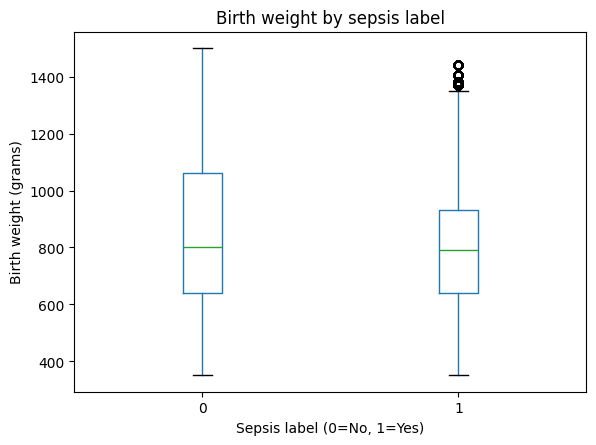

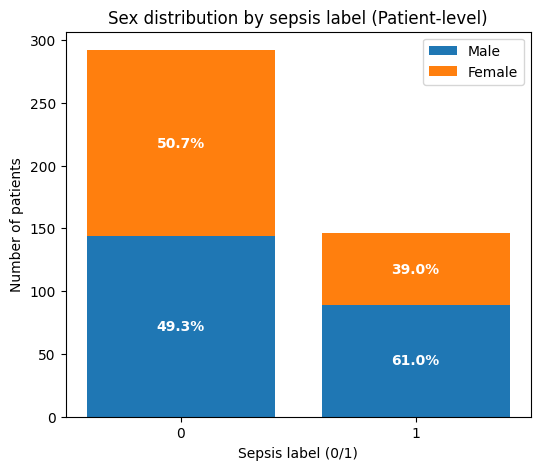

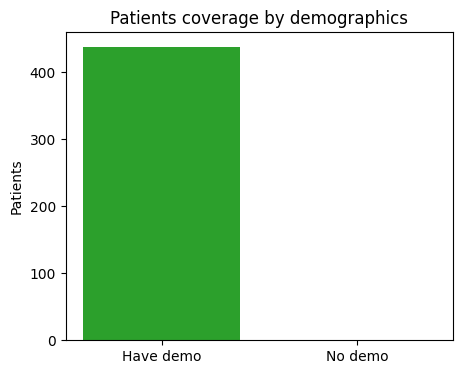

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# اقرأ النسخة المدموجة
df = pd.read_csv("data/processed/undersampled_with_demo.csv")

# ==================================================
# 1) Birth weight by sepsis label (Boxplot)
# ==================================================
plt.figure(figsize=(6,5))
df.boxplot(column="birth_weight", by="sepsis_window", grid=False)
plt.title("Birth weight by sepsis label")
plt.suptitle("")  # يشيل العنوان الإضافي
plt.xlabel("Sepsis label (0=No, 1=Yes)")
plt.ylabel("Birth weight (grams)")
plt.show()

# ==================================================
# 2) Sex distribution by label (Patient-level Stacked bar)
# ==================================================
# واحد لكل مريض: sex ثابت، label = 1 إذا عنده أي sepsis_window=1
patients = df.groupby("new_id").agg({
    "sex": "first",
    "sepsis_window": "max"
}).reset_index()

# Crosstab على مستوى المرضى
tab = pd.crosstab(patients["sepsis_window"], patients["sex"])

labels = tab.index.astype(str).tolist()
male   = tab[1].tolist() if 1 in tab.columns else [0]*len(labels)
female = tab[0].tolist() if 0 in tab.columns else [0]*len(labels)

plt.figure(figsize=(6,5))
plt.bar(labels, male, label="Male")
plt.bar(labels, female, bottom=male, label="Female")
plt.title("Sex distribution by sepsis label (Patient-level)")
plt.xlabel("Sepsis label (0/1)")
plt.ylabel("Number of patients")
plt.legend()

# إضافة نسب مئوية
for i, (m, f) in enumerate(zip(male, female)):
    total = m + f
    if total > 0:
        plt.text(i, m/2, f"{m/total:.1%}", ha="center", va="center",
                 color="white", fontsize=10, fontweight="bold")
        plt.text(i, m + f/2, f"{f/total:.1%}", ha="center", va="center",
                 color="white", fontsize=10, fontweight="bold")

plt.show()

# ==================================================
# 3) Coverage check (قبل/بعد الدمج)
# ==================================================
feat = pd.read_csv("data/processed/undersampled_by_patient.csv")
demo = pd.read_csv(r"C:\Users\96277\nicu-sepsis\data\raw\demographics.csv")

ids_feat = set(feat["new_id"].unique())
ids_demo = set(demo["new_id"].unique())

have_demo = len(ids_feat & ids_demo)
no_demo   = len(ids_feat - ids_demo)

plt.figure(figsize=(5,4))
plt.bar(["Have demo","No demo"], [have_demo, no_demo], color=["tab:green","tab:red"])
plt.title("Patients coverage by demographics")
plt.ylabel("Patients")
plt.show()


In [9]:
import pandas as pd
from pathlib import Path

FEATURES_PATH = r"data/processed/undersampled_by_patient.csv"
DEMOGRAPHICS_PATH = r"C:\Users\96277\nicu-sepsis\data\raw\demographics.csv"
OUT_PATH = r"data/processed/undersampled_with_demo.csv"

# اقرأ الملفات
df_feat = pd.read_csv(FEATURES_PATH)
df_demo = pd.read_csv(DEMOGRAPHICS_PATH)

# فلترة demographics على حسب المرضى الموجودين في undersampled file
valid_ids = df_feat["new_id"].unique()
df_demo_filtered = df_demo[df_demo["new_id"].isin(valid_ids)]

# الدمج
df_merged = df_feat.merge(df_demo_filtered, on="new_id", how="left")

# حفظ النسخة
Path(OUT_PATH).parent.mkdir(parents=True, exist_ok=True)
df_merged.to_csv(OUT_PATH, index=False)

print("Merged shape:", df_merged.shape)
print("Unique patients:", df_merged["new_id"].nunique())
print(f"File saved to: {OUT_PATH}")

# عرض عينات
print("\n=== Sample from merged file ===")
display(df_merged.sample(10, random_state=1))


Merged shape: (4483483, 17)
Unique patients: 438
File saved to: data/processed/undersampled_with_demo.csv

=== Sample from merged file ===


,new_id,seconds_since_birth,mean_hr,mean_spo2,sd_hr,sd_spo2,skewness_hr,skewness_spo2,kurtosis_hr,kurtosis_spo2,max_xc_hr_spo2,min_xc_hr_spo2,sub,sepsis_window,blackout_window,sex,birth_weight
1412156,69691160,18532080,146.713333,96.266667,6.871332,3.081212,0.277707,-2.709433,3.303847,11.285708,-0.207202,-0.614217,0,0,0,1,810.000000
975977,66812507,1648140,168.400000,98.043333,12.750500,4.478278,-0.191744,-3.569207,3.984779,16.390488,0.233030,-0.232637,0,0,0,0,1460.000000
3870882,49790722,2514420,147.812709,95.966555,6.626546,2.289211,-0.653989,-0.848221,4.094521,2.666643,0.024575,-0.636178,0,0,0,1,830.000000
3271985,72638418,20828160,152.003344,99.806020,13.633629,0.569791,-1.469395,-3.479913,3.707735,15.624416,-0.124012,-0.224393,0,0,0,1,620.000000
147907,19333269,863340,147.920000,93.623333,3.930023,1.213685,-0.766355,-1.666369,21.270997,8.719552,0.012748,-0.187567,0,0,0,0,589.999974
1844367,98620092,3326580,169.976667,95.900000,5.253709,1.712633,0.478927,-1.925076,2.215454,8.999548,0.088060,-0.252680,0,0,0,0,1140.000000
20496,19558287,6412440,166.793333,92.870000,5.618646,3.537629,-0.107259,-2.318720,4.852088,10.934374,0.326136,-0.225887,0,0,0,1,720.000029
1532053,27157144,4407960,196.253333,90.046667,8.253660,5.022806,0.067273,-1.083978,2.946268,3.541427,-0.379344,-0.617870,0,0,0,1,700.000000
3853273,83720765,2908260,186.367003,93.734007,2.601323,8.087358,0.337008,-1.194893,2.539269,2.929837,-0.117516,-0.537625,0,0,0,0,1310.000000
3227953,6016562,4532400,154.876667,100.000000,7.925750,0.000000,-0.498955,0.000000,2.605528,3.000000,0.000000,0.000000,0,0,0,1,1417.000000


In [5]:
# 1) ثبّت إن عدد المرضى المصابين ما تغيّر (=146)
import pandas as pd
dfm = pd.read_csv("data/processed/undersampled_with_demo.csv")
int(dfm.groupby("new_id")["sepsis_window"].max().sum())


146

In [6]:
# 2) تأكد ما في نواقص بالديموغرافيا
dfm[["sex","birth_weight"]].isna().sum()


sex             0
birth_weight    0
dtype: int64

In [7]:
# 3) تأكد إنه ما في تكرار بالديموغرافيا (واحد لكل مريض)
demo = pd.read_csv(r"C:\Users\96277\nicu-sepsis\data\raw\demographics.csv")
demo["new_id"].duplicated().sum()


np.int64(0)

In [10]:
import pandas as pd
from pathlib import Path

IN_PATH  = "data/processed/undersampled_with_demo.csv"
OUT_PATH = "data/processed/undersampled_with_demo_clipped.csv"

# حدود فيزيولوجية تقريبية للرضّع
HR_LO, HR_HI = 40, 240
SPO2_LO, SPO2_HI = 50, 100

df = pd.read_csv(IN_PATH)

# احصاءات قبل القص
bef_hr_oor = ((df["mean_hr"]   < HR_LO)  | (df["mean_hr"]   > HR_HI)).sum()
bef_sp_oor = ((df["mean_spo2"] < SPO2_LO)| (df["mean_spo2"] > SPO2_HI)).sum()
print("Before clip → out-of-range counts:")
print(f"  mean_hr:   {bef_hr_oor}")
print(f"  mean_spo2: {bef_sp_oor}")

# القص (clip) — ما بنلمس أي أعمدة ثانية
df["mean_hr"]   = df["mean_hr"].clip(HR_LO, HR_HI)
df["mean_spo2"] = df["mean_spo2"].clip(SPO2_LO, SPO2_HI)

# احصاءات بعد القص
aft_hr_oor = ((df["mean_hr"]   < HR_LO)  | (df["mean_hr"]   > HR_HI)).sum()
aft_sp_oor = ((df["mean_spo2"] < SPO2_LO)| (df["mean_spo2"] > SPO2_HI)).sum()
print("\nAfter clip → out-of-range counts:")
print(f"  mean_hr:   {aft_hr_oor}")
print(f"  mean_spo2: {aft_sp_oor}")

# كم صف اتعدّل فعليًا؟
changed_hr = (df["mean_hr"].eq(HR_LO) | df["mean_hr"].eq(HR_HI)).sum()
changed_sp = (df["mean_spo2"].eq(SPO2_LO) | df["mean_spo2"].eq(SPO2_HI)).sum()
print("\nRows adjusted (hit bounds):")
print(f"  mean_hr clipped rows:   {changed_hr}")
print(f"  mean_spo2 clipped rows: {changed_sp}")

# حفظ نسخة جديدة (الأصل يظل كما هو)
Path(OUT_PATH).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_PATH, index=False)
print(f"\nSaved: {OUT_PATH}")


Before clip → out-of-range counts:
  mean_hr:   15
  mean_spo2: 127

After clip → out-of-range counts:
  mean_hr:   0
  mean_spo2: 0

Rows adjusted (hit bounds):
  mean_hr clipped rows:   15
  mean_spo2 clipped rows: 37983

Saved: data/processed/undersampled_with_demo_clipped.csv


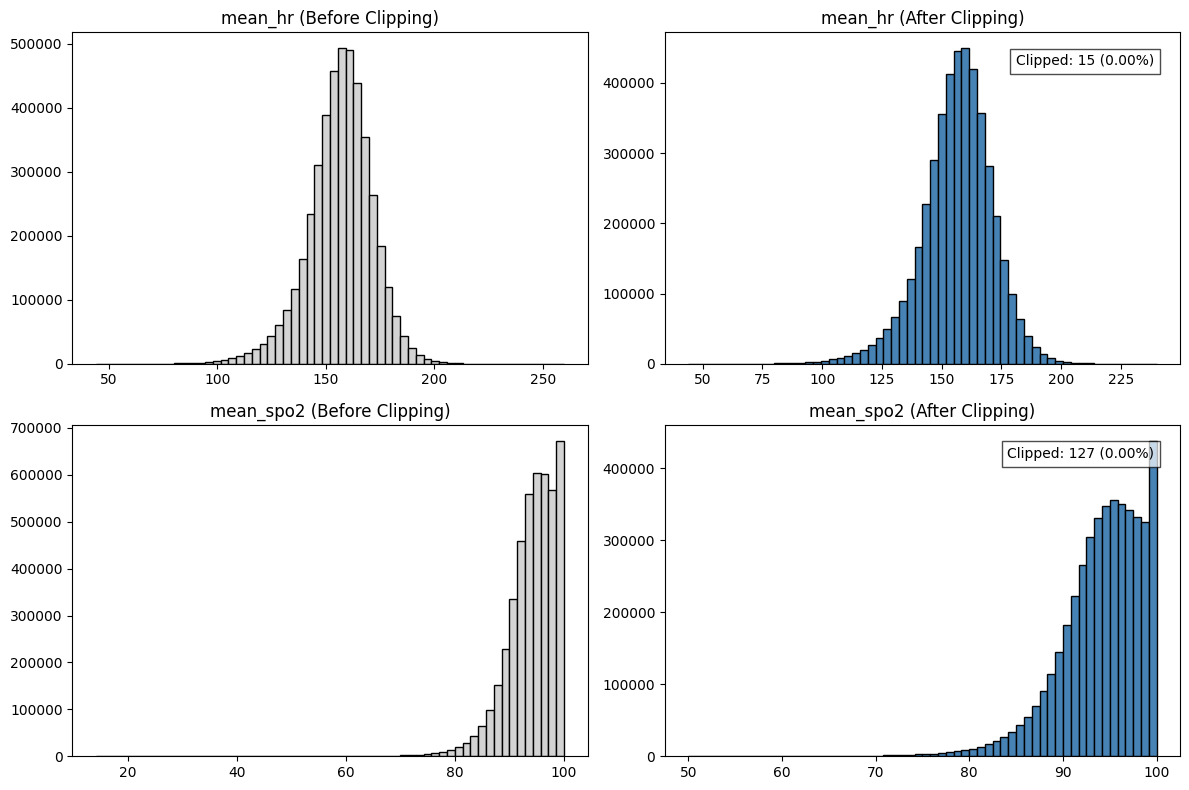

C:\Users\96277\AppData\Local\Temp\ipykernel_15848\1803035219.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([before["mean_hr"], after["mean_hr"]], labels=["Before","After"])
C:\Users\96277\AppData\Local\Temp\ipykernel_15848\1803035219.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([before["mean_spo2"], after["mean_spo2"]], labels=["Before","After"])


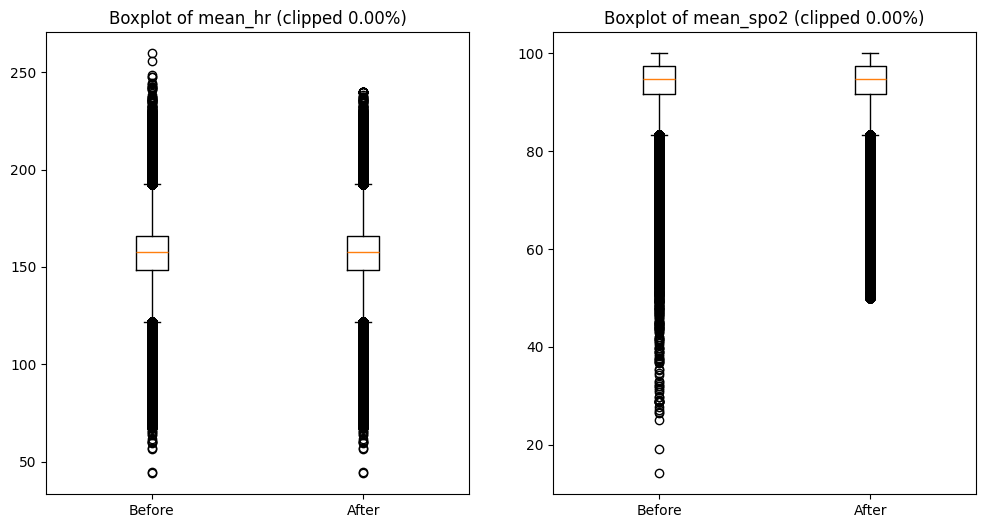

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# اقرأ الملفات
before = pd.read_csv("data/processed/undersampled_with_demo.csv")
after  = pd.read_csv("data/processed/undersampled_with_demo_clipped.csv")

# احسب عدد القيم المقصوصة
n_total_hr = len(before["mean_hr"])
n_clipped_hr = (before["mean_hr"] != after["mean_hr"]).sum()
pct_hr = 100 * n_clipped_hr / n_total_hr

n_total_spo2 = len(before["mean_spo2"])
n_clipped_spo2 = (before["mean_spo2"] != after["mean_spo2"]).sum()
pct_spo2 = 100 * n_clipped_spo2 / n_total_spo2

# ==================================================
# Histogram مع annotation
# ==================================================
fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes[0,0].hist(before["mean_hr"], bins=60, color="lightgray", edgecolor="black")
axes[0,0].set_title("mean_hr (Before Clipping)")

axes[0,1].hist(after["mean_hr"], bins=60, color="steelblue", edgecolor="black")
axes[0,1].set_title("mean_hr (After Clipping)")
axes[0,1].text(0.95, 0.9, f"Clipped: {n_clipped_hr} ({pct_hr:.2f}%)", 
               transform=axes[0,1].transAxes, ha="right", fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

axes[1,0].hist(before["mean_spo2"], bins=60, color="lightgray", edgecolor="black")
axes[1,0].set_title("mean_spo2 (Before Clipping)")

axes[1,1].hist(after["mean_spo2"], bins=60, color="steelblue", edgecolor="black")
axes[1,1].set_title("mean_spo2 (After Clipping)")
axes[1,1].text(0.95, 0.9, f"Clipped: {n_clipped_spo2} ({pct_spo2:.2f}%)", 
               transform=axes[1,1].transAxes, ha="right", fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# ==================================================
# Boxplot مع annotation
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].boxplot([before["mean_hr"], after["mean_hr"]], labels=["Before","After"])
axes[0].set_title(f"Boxplot of mean_hr (clipped {pct_hr:.2f}%)")

axes[1].boxplot([before["mean_spo2"], after["mean_spo2"]], labels=["Before","After"])
axes[1].set_title(f"Boxplot of mean_spo2 (clipped {pct_spo2:.2f}%)")

plt.show()


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

IN_PATH = "data/processed/undersampled_with_demo_clipped.csv"
OUT_DIR = Path("data/processed/splits_by_patient")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(IN_PATH)

ID_COL = "new_id"
LABEL_COL = "sepsis_window"
RANDOM_STATE = 42

# ملصق المريض: مريض مصاب إذا عنده أي صف = 1
patient_df = (
    df.groupby(ID_COL)[LABEL_COL].max().reset_index().rename(columns={LABEL_COL: "patient_label"})
)

# IDs و Labels
ids = patient_df[ID_COL].values
y   = patient_df["patient_label"].values

# 70% train, والباقي temp (30%)
ids_train, ids_temp, y_train, y_temp = train_test_split(
    ids, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# قسّم الـ 30% إلى 15% val و 15% test
ids_val, ids_test, y_val, y_test = train_test_split(
    ids_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

# فلترة الصفوف حسب IDs
train_df = df[df[ID_COL].isin(ids_train)].copy()
val_df   = df[df[ID_COL].isin(ids_val)].copy()
test_df  = df[df[ID_COL].isin(ids_test)].copy()

# حفظ
train_path = OUT_DIR / "train.csv"
val_path   = OUT_DIR / "val.csv"
test_path  = OUT_DIR / "test.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

# تقارير سريعة
def report(name, part_df):
    pat = part_df[ID_COL].nunique()
    rows = len(part_df)
    pos_rows = (part_df[LABEL_COL] == 1).sum()
    neg_rows = (part_df[LABEL_COL] == 0).sum()
    pat_lab = part_df.groupby(ID_COL)[LABEL_COL].max()
    pos_pat = (pat_lab == 1).sum()
    neg_pat = (pat_lab == 0).sum()
    print(f"{name}: patients={pat} (pos={pos_pat}, neg={neg_pat}) | rows={rows:,} (pos_rows={pos_rows:,}, neg_rows={neg_rows:,})")

print("== Patient-level stratified split ==")
report("TRAIN", train_df)
report("VAL  ", val_df)
report("TEST ", test_df)

# تأكد ما في تداخل IDs بين المجموعات
set_train, set_val, set_test = set(ids_train), set(ids_val), set(ids_test)
print("\nOverlap checks (should be 0):")
print("train ∩ val :", len(set_train & set_val))
print("train ∩ test:", len(set_train & set_test))
print("val   ∩ test:", len(set_val & set_test))

print(f"\nSaved to:\n{train_path}\n{val_path}\n{test_path}")


== Patient-level stratified split ==
TRAIN: patients=306 (pos=102, neg=204) | rows=3,096,499 (pos_rows=15,352, neg_rows=3,081,147)
VAL  : patients=66 (pos=22, neg=44) | rows=769,979 (pos_rows=3,027, neg_rows=766,952)
TEST : patients=66 (pos=22, neg=44) | rows=617,005 (pos_rows=3,875, neg_rows=613,130)

Overlap checks (should be 0):
train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0

Saved to:
data\processed\splits_by_patient\train.csv
data\processed\splits_by_patient\val.csv
data\processed\splits_by_patient\test.csv


C:\Users\96277\AppData\Local\Temp\ipykernel_15848\4116127458.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\96277\AppData\Local\Temp\ipykernel_15848\4116127458.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(


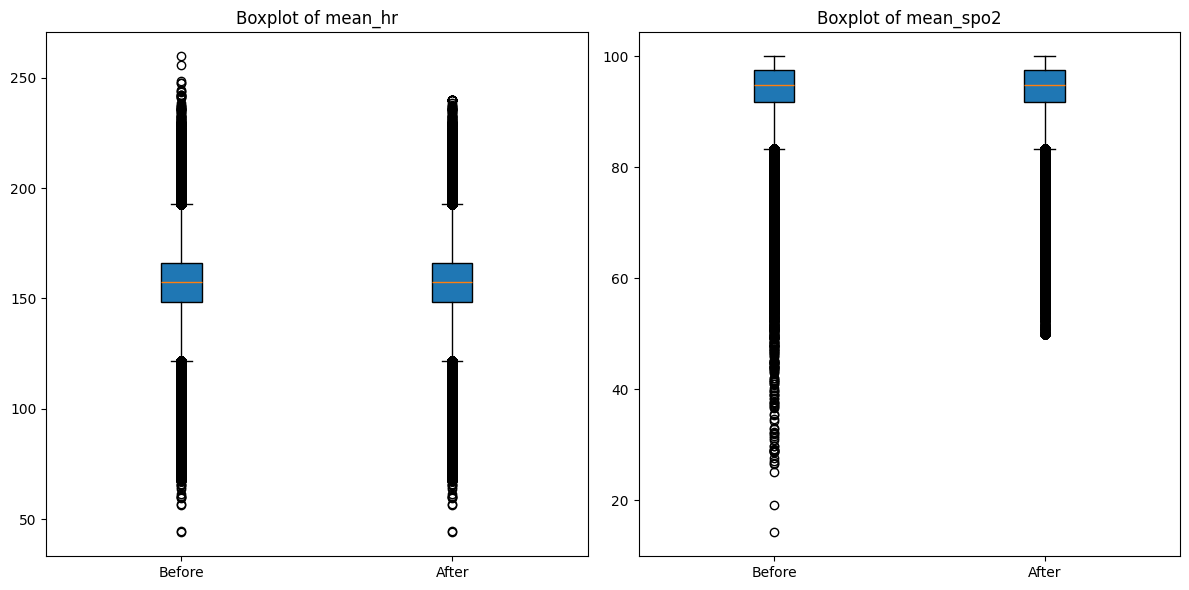

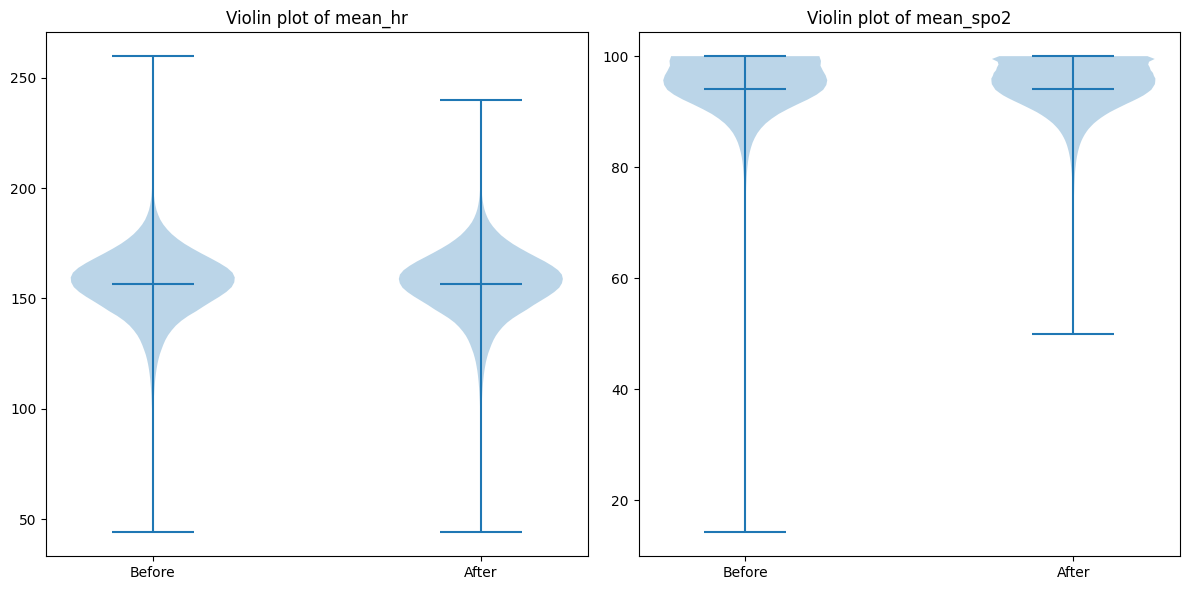

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# تحميل الملفات
before = pd.read_csv("data/processed/undersampled_with_demo.csv")
after  = pd.read_csv("data/processed/undersampled_with_demo_clipped.csv")

cols = ["mean_hr", "mean_spo2"]

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, col in enumerate(cols):
    axes[i].boxplot(
        [before[col].dropna(), after[col].dropna()],
        labels=["Before", "After"],
        patch_artist=True
    )
    axes[i].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# Violin plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, col in enumerate(cols):
    axes[i].violinplot(
        [before[col].dropna(), after[col].dropna()],
        positions=[1, 2],
        showmeans=True
    )
    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(["Before", "After"])
    axes[i].set_title(f"Violin plot of {col}")
plt.tight_layout()
plt.show()


In [12]:
import pandas as pd
import numpy as np

# إعدادات النوافذ
T_FIX   = 144    # 24 ساعة
STRIDE  = 6      # ساعة
HORIZON = 144    # ✅ 24 ساعة قادمة
FEATURES = [
    "mean_hr","mean_spo2","sd_hr","sd_spo2",
    "skewness_hr","skewness_spo2","kurtosis_hr","kurtosis_spo2"
]

df = pd.read_csv("data/processed/splits_by_patient/train.csv")

# اختَر مريض إيجابي للتجربة
pos_patients = df.groupby("new_id")["sepsis_window"].max()
pos_ids = pos_patients[pos_patients==1].index.tolist()
pid = pos_ids[0] if len(pos_ids)>0 else df["new_id"].iloc[0]

d = df[df["new_id"]==pid].sort_values("seconds_since_birth").reset_index(drop=True)
print(f"Patient {pid} rows = {len(d)}")

X_list, y_list = [], []
n, i = len(d), 0
while i + T_FIX - 1 < n:
    i_start = i
    i_end   = i + T_FIX - 1

    # ✅ عدّل شرط الـ blackout: ارفض النافذة فقط إذا نهايتها داخل البلاك أوت
    if "blackout_window" in d.columns and int(d.loc[i_end, "blackout_window"]) == 1:
        i += STRIDE
        continue
    # (بديل اختياري) امنع blackout فقط بآخر 6 ساعات:
    # K = 36
    # blk_start = max(i_start, i_end - K + 1)
    # if "blackout_window" in d.columns and d.loc[blk_start:i_end, "blackout_window"].max() == 1:
    #     i += STRIDE; continue

    window = d.loc[i_start:i_end, FEATURES].to_numpy(dtype=np.float32)

    j1 = i_end + 1
    j2 = min(i_end + HORIZON, n - 1)
    future_has_sepsis = (d.loc[j1:j2, "sepsis_window"] == 1).any() if j1 <= j2 else False

    X_list.append(window)
    y_list.append(1 if future_has_sepsis else 0)
    i += STRIDE

X = np.stack(X_list, axis=0) if X_list else np.empty((0, T_FIX, len(FEATURES)), dtype=np.float32)
y = np.array(y_list, dtype=np.int64)

print(f"Windows made: {len(y)}  |  Pos labels: {int((y==1).sum())}  |  Neg labels: {int((y==0).sum())}")
print("First 20 labels:", y[:20].tolist())


Patient 706395 rows = 20367
Windows made: 3228  |  Pos labels: 48  |  Neg labels: 3180
First 20 labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# مسارات الملفات
DATA_CSV  = "data/processed/undersampled_with_demo_clipped.csv"
SPLIT_DIR = Path("data/processed/splits_by_patient")
OUT_DIR   = Path("data/processed/windows_24h"); OUT_DIR.mkdir(parents=True, exist_ok=True)

# أعمدة أساسية
ID_COL       = "new_id"
TIME_COL     = "seconds_since_birth"
LABEL_COL    = "sepsis_window"
BLACKOUT_COL = "blackout_window"   # اختياري

# الميزات (عدّلها إذا لزم)
FEATURES = [
    "mean_hr","mean_spo2","sd_hr","sd_spo2",
    "skewness_hr","skewness_spo2","kurtosis_hr","kurtosis_spo2"
]

# نافذة 24h بخطوة 10 دقائق
T_FIX   = 144   # طول النافذة (24h)
STRIDE  = 6     # كل 6 ستبس = 60 دقيقة
HORIZON = 144   # نتنبأ بوجود onset خلال 24h القادمة

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [2]:
# === Build 24h Forecast Label for train/val/test ===
from pathlib import Path
import numpy as np, pandas as pd

# --- الإعدادات ---
DATA_DIR   = Path("data/processed/splits_by_patient").resolve()
ID_COL     = "new_id"
TIME_COL   = "seconds_since_birth"
LABEL_COL  = "sepsis_window"
HOURS      = 24
HORIZON_S  = HOURS * 3600  # 24h بالثواني

files = ["train.csv", "val.csv", "test.csv"]
assert all((DATA_DIR/f).exists() for f in files), f"ملف مفقود داخل {DATA_DIR}"

def add_forecast_label_per_patient(df: pd.DataFrame,
                                   id_col=ID_COL,
                                   time_col=TIME_COL,
                                   label_col=LABEL_COL,
                                   horizon_seconds=HORIZON_S,
                                   out_col="y_forecast_24h") -> pd.DataFrame:
    """
    نحدد الصفوف التي يوجد بعدها حدث Sepsis=1 خلال الـ 24 ساعة القادمة.
    المنطق: لأي حدث إيجابي عند الزمن te -> كل الصفوف التي زمنها t في الفترة [te-24h, te) تصبح 1.
    هذا يحافظ على السببية (ما منستخدم معلومات من المستقبل وقت التنبؤ).
    """
    if out_col in df.columns:
        df = df.drop(columns=[out_col])

    # تأكد من الترتيب داخل كل مريض
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)

    yf = np.zeros(len(df), dtype=np.int8)

    # نشتغل مريض-مريض لتسريع البحث عبر searchsorted
    for pid, idx in df.groupby(id_col, sort=False).indices.items():
        # indices of this patient's slice
        start, stop = idx[0], idx[-1] + 1
        g = df.iloc[start:stop]

        times = g[time_col].to_numpy(dtype=np.int64)
        y     = g[label_col].to_numpy(dtype=np.int8)

        # مواقع الأحداث الإيجابية
        pos_idx = np.flatnonzero(y == 1)
        if pos_idx.size == 0:
            continue

        # لكل حدث إيجابي عند te، علّم المدى [te-24h, te)
        # نحسب te من الزمن الفعلي
        te_arr = times[pos_idx]
        # left = أول موقع >= te - 24h
        left_bounds  = np.searchsorted(times, te_arr - horizon_seconds, side="left")
        # right = أول موقع >= te  (مدى نصف مفتوح)
        right_bounds = np.searchsorted(times, te_arr, side="left")

        # علّم جميع الفترات
        for L, R in zip(left_bounds, right_bounds):
            if L < R:  # لو في نافذة غير فارغة
                yf[start + L : start + R] = 1

    out = df.copy()
    out[out_col] = yf.astype(np.int8)
    return out

def process_file(in_name: str):
    path = DATA_DIR / in_name
    df   = pd.read_csv(path)
    # فحوصات أساسية
    for c in (ID_COL, TIME_COL, LABEL_COL):
        if c not in df.columns:
            raise ValueError(f"العمود {c} غير موجود في {in_name}")

    out_df = add_forecast_label_per_patient(df)
    out_name = in_name.replace(".csv", "_forecast24.csv")
    out_path = DATA_DIR / out_name
    out_df.to_csv(out_path, index=False)

    # إحصائيات سريعة
    rate = out_df["y_forecast_24h"].mean()
    print(f"✔ {in_name} → {out_name} | shape={out_df.shape} | positive_rate={rate:.4f}")

for f in files:
    process_file(f)

print("\nتم إنشاء النسخ مع العمود الجديد y_forecast_24h ✅")


✔ train.csv → train_forecast24.csv | shape=(3096499, 18) | positive_rate=0.0097
✔ val.csv → val_forecast24.csv | shape=(769979, 18) | positive_rate=0.0075
✔ test.csv → test_forecast24.csv | shape=(617005, 18) | positive_rate=0.0125

تم إنشاء النسخ مع العمود الجديد y_forecast_24h ✅


In [3]:
import pandas as pd
from pathlib import Path

orig = pd.read_csv(Path("data/processed/splits_by_patient/train.csv"))
new  = pd.read_csv(Path("data/processed/splits_by_patient/train_forecast24.csv"))

# لازم يكونوا بنفس الطول والترتيب بعد sort بنفس المفاتيح:
KEYS = ["new_id", "seconds_since_birth"]
orig = orig.sort_values(KEYS).reset_index(drop=True)
new  = new.sort_values(KEYS).reset_index(drop=True)

diff = (orig["sepsis_window"] != new["y_forecast_24h"]).mean()
print(f"نسبة الصفوف اللي اختلف فيها الليبل: {diff:.3%}")
print("معدّل sepsis_window الأصلي:", orig["sepsis_window"].mean())
print("معدّل y_forecast_24h الجديد:", new["y_forecast_24h"].mean())


نسبة الصفوف اللي اختلف فيها الليبل: 0.486%
معدّل sepsis_window الأصلي: 0.004957857244584933
معدّل y_forecast_24h الجديد: 0.009745845227142008


In [4]:
import pandas as pd
from pathlib import Path

# حمل الملفين
orig = pd.read_csv(Path("data/processed/splits_by_patient/train.csv"))
new  = pd.read_csv(Path("data/processed/splits_by_patient/train_forecast24.csv"))

# ترتيب لضمان التطابق
KEYS = ["new_id", "seconds_since_birth"]
orig = orig.sort_values(KEYS).reset_index(drop=True)
new  = new.sort_values(KEYS).reset_index(drop=True)

# المقارنة
comp = pd.crosstab(orig["sepsis_window"], new["y_forecast_24h"],
                   rownames=["الأصلي"], colnames=["الجديد"])

print("📊 مصفوفة المقارنة بين الليبلات:")
print(comp)

# فروقات واضحة
changed_0_to_1 = ((orig["sepsis_window"] == 0) & (new["y_forecast_24h"] == 1)).sum()
changed_1_to_0 = ((orig["sepsis_window"] == 1) & (new["y_forecast_24h"] == 0)).sum()

print(f"\n➡️ عدد الصفوف 0→1: {changed_0_to_1:,}")
print(f"➡️ عدد الصفوف 1→0: {changed_1_to_0:,}")

# الإجماليات
print("\n📌 إجمالي الأصلي:")
print(orig["sepsis_window"].value_counts())

print("\n📌 إجمالي الجديد:")
print(new["y_forecast_24h"].value_counts())


📊 مصفوفة المقارنة بين الليبلات:
الجديد        0      1
الأصلي                
0       3066209  14938
1           112  15240

➡️ عدد الصفوف 0→1: 14,938
➡️ عدد الصفوف 1→0: 112

📌 إجمالي الأصلي:
sepsis_window
0    3081147
1      15352
Name: count, dtype: int64

📌 إجمالي الجديد:
y_forecast_24h
0    3066321
1      30178
Name: count, dtype: int64


In [5]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/processed/splits_by_patient")
IN_FILE  = DATA_DIR / "train_forecast24.csv"
OUT_FILE = DATA_DIR / "train_forecast24_undersampled005.csv"

df = pd.read_csv(IN_FILE)

ID_COL = "new_id"
TIME_COL = "seconds_since_birth"
LABEL_COL = "y_forecast_24h"

def undersample_per_patient(g: pd.DataFrame, frac_keep=0.05):
    pos = g[g[LABEL_COL] == 1]
    neg = g[g[LABEL_COL] == 0]
    neg_sample = neg.sample(frac=frac_keep, random_state=42)
    return pd.concat([pos, neg_sample], axis=0)

df_balanced = (
    df.groupby(ID_COL, group_keys=False)
      .apply(lambda g: undersample_per_patient(g, frac_keep=0.05))
      .sort_values([ID_COL, TIME_COL])
      .reset_index(drop=True)
)

df_balanced.to_csv(OUT_FILE, index=False)

print(f"✔ saved {OUT_FILE} | shape={df_balanced.shape}")
print(df_balanced[LABEL_COL].value_counts())
print(df_balanced[LABEL_COL].value_counts(normalize=True))


C:\Users\96277\AppData\Local\Temp\ipykernel_12144\2393631590.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: undersample_per_patient(g, frac_keep=0.05))


✔ saved data\processed\splits_by_patient\train_forecast24_undersampled005.csv | shape=(183494, 18)
y_forecast_24h
0    153316
1     30178
Name: count, dtype: int64
y_forecast_24h
0    0.835537
1    0.164463
Name: proportion, dtype: float64


In [6]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/processed/splits_by_patient")

for split in ["val_forecast24.csv", "test_forecast24.csv"]:
    path = DATA_DIR / split
    df = pd.read_csv(path)

    counts = df["y_forecast_24h"].value_counts()
    props  = df["y_forecast_24h"].value_counts(normalize=True)

    print(f"\n=== {split} ===")
    print("عدد الصفوف:", len(df))
    print("عدد 0:", counts.get(0, 0), f"({props.get(0, 0):.2%})")
    print("عدد 1:", counts.get(1, 0), f"({props.get(1, 0):.2%})")



=== val_forecast24.csv ===
عدد الصفوف: 769979
عدد 0: 764192 (99.25%)
عدد 1: 5787 (0.75%)

=== test_forecast24.csv ===
عدد الصفوف: 617005
عدد 0: 609323 (98.75%)
عدد 1: 7682 (1.25%)


In [7]:
from pathlib import Path
import numpy as np, pandas as pd

DATA_DIR = Path("data/processed/splits_by_patient")
IN_FILE  = DATA_DIR / "train_forecast24.csv"
OUT_FILE = DATA_DIR / "train_forecast24_patientaware.csv"

ID_COL    = "new_id"
TIME_COL  = "seconds_since_birth"
YF_COL    = "y_forecast_24h"
Y_NOW_COL = "sepsis_window"   # نستخدمه فقط للتعرّف على المرضى المصابين

# باراميترات قابلة للتعديل
NEAR_HOURS          = 12          # “قريب من الخطر” خلال 12 ساعة
NEAR_SEC            = NEAR_HOURS * 3600
KEEP_NEAR_NEG_FRAC  = 0.60        # نسبة الاحتفاظ من السوالب القريبة
KEEP_FAR_NEG_FRAC   = 0.02        # نسبة الاحتفاظ من السوالب البعيدة
KEEP_HEALTHY_FRAC   = 0.05        # نسبة الاحتفاظ من السوالب عند الأصحاء
MIN_ROWS_PER_PAT    = 50          # لا ننزل عن هيك صفوف لكل مريض (حماية)

rng = np.random.default_rng(42)

df = pd.read_csv(IN_FILE).sort_values([ID_COL, TIME_COL]).reset_index(drop=True)

# وسم المريض: مصاب إذا عنده أي صف sepsis_window=1
patient_label = (
    df.groupby(ID_COL)[Y_NOW_COL]
      .max()
      .rename("patient_label")
      .astype(int)
      .reset_index()
)
df = df.merge(patient_label, on=ID_COL, how="left")

def sample_patient_group(g: pd.DataFrame) -> pd.DataFrame:
    # احتفظ بكل الإيجابيات (forecast=1)
    keep_mask = (g[YF_COL] == 1).to_numpy()

    if g["patient_label"].iat[0] == 1:
        # مريض مصاب: نتعامل مع 0 بحسب قربها من نافذة الخطر
        times = g[TIME_COL].to_numpy(np.int64)
        pos_times = times[g[YF_COL].to_numpy() == 1]

        neg_idx = np.flatnonzero((g[YF_COL].to_numpy() == 0))
        if neg_idx.size > 0:
            if pos_times.size > 0:
                # أقل مسافة زمنية لأي صف forecast=1
                d = np.abs(times[neg_idx, None] - pos_times[None, :]).min(axis=1)
            else:
                # لو ما في forecast=1 (حالات نادرة) اعتبر الكل بعيد
                d = np.full(neg_idx.shape[0], fill_value=NEAR_SEC+1, dtype=np.int64)

            near = d <= NEAR_SEC
            far  = ~near

            # قرعة احتفاظ
            keep_near = rng.random(near.sum()) < KEEP_NEAR_NEG_FRAC
            keep_far  = rng.random(far.sum())  < KEEP_FAR_NEG_FRAC

            sel = np.zeros_like(neg_idx, dtype=bool)
            sel[near] = keep_near
            sel[far]  = keep_far

            keep_mask[neg_idx] = sel

    else:
        # مريض غير مصاب: نأخذ نسبة صغيرة من السوالب
        neg_idx = np.flatnonzero((g[YF_COL].to_numpy() == 0))
        if neg_idx.size > 0:
            sel = rng.random(neg_idx.size) < KEEP_HEALTHY_FRAC
            keep_mask[neg_idx] = sel

    out = g[keep_mask]

    # ضمان حد أدنى لكل مريض
    if len(out) < min(MIN_ROWS_PER_PAT, len(g)):
        extra_need = min(MIN_ROWS_PER_PAT, len(g)) - len(out)
        # خذ من الباقي عشوائيًا بدون تكرار
        remain_idx = np.where(~keep_mask)[0]
        if remain_idx.size > 0:
            take = remain_idx[rng.choice(remain_idx.size, size=min(extra_need, remain_idx.size), replace=False)]
            out = pd.concat([out, g.iloc[take]], axis=0)

    return out.sort_values(TIME_COL)

# تطبيق per-patient
out = (
    df.groupby(ID_COL, group_keys=False)
      .apply(sample_patient_group)
      .sort_values([ID_COL, TIME_COL])
      .reset_index(drop=True)
)

# حفظ النسخة
cols = [c for c in df.columns if c != "patient_label"]
out[cols].to_csv(OUT_FILE, index=False)

# تقارير سريعة
def dist(x): 
    vc = x.value_counts()
    pr = x.value_counts(normalize=True)
    return f"0: {vc.get(0,0):,} ({pr.get(0,0):.2%}) | 1: {vc.get(1,0):,} ({pr.get(1,0):.2%})"

print(f"✔ saved {OUT_FILE} | shape={out.shape}")
print("قبل  :", dist(df[YF_COL]))
print("بعد  :", dist(out[YF_COL]))
print("عدد المرضى قبل/بعد:", df[ID_COL].nunique(), "/", out[ID_COL].nunique())


C:\Users\96277\AppData\Local\Temp\ipykernel_12144\779141522.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_patient_group)


✔ saved data\processed\splits_by_patient\train_forecast24_patientaware.csv | shape=(146834, 19)
قبل  : 0: 3,066,321 (99.03%) | 1: 30,178 (0.97%)
بعد  : 0: 116,656 (79.45%) | 1: 30,178 (20.55%)
عدد المرضى قبل/بعد: 306 / 306


In [8]:
from pathlib import Path
import numpy as np, pandas as pd

DATA_DIR = Path("data/processed/splits_by_patient")
IN_FILE  = DATA_DIR / "train_forecast24_undersampled005.csv"   # ← الملف الحالي
OUT_FILE = DATA_DIR / "train_forecast24_undersampled005_patientaware.csv"

ID_COL, TIME_COL = "new_id", "seconds_since_birth"
YF_COL, Y_NOW_COL = "y_forecast_24h", "sepsis_window"

# باراميترات (أقوى قرب الحدث، لكن ارفع healthy شوي لأن الملف أصلاً مقصوص)
NEAR_HOURS = 12
NEAR_SEC   = NEAR_HOURS * 3600
KEEP_NEAR_NEG_FRAC = 0.60   # من 0 القريبة للمصاب
KEEP_FAR_NEG_FRAC  = 0.05   # من 0 البعيدة للمصاب (رفعناها من 0.02)
KEEP_HEALTHY_FRAC  = 0.10   # من 0 عند الأصحّاء (رفعناها من 0.05)
MIN_ROWS_PER_PAT   = 50

rng = np.random.default_rng(42)
df = pd.read_csv(IN_FILE).sort_values([ID_COL, TIME_COL]).reset_index(drop=True)

patient_label = df.groupby(ID_COL)[Y_NOW_COL].max().rename("patient_label").astype(int).reset_index()
df = df.merge(patient_label, on=ID_COL, how="left")

def sample_patient_group(g: pd.DataFrame) -> pd.DataFrame:
    keep = (g[YF_COL] == 1).to_numpy()
    if g["patient_label"].iat[0] == 1:
        times = g[TIME_COL].to_numpy(np.int64)
        pos_times = times[g[YF_COL].to_numpy() == 1]
        neg_idx = np.flatnonzero(g[YF_COL].to_numpy() == 0)
        if neg_idx.size:
            if pos_times.size:
                d = np.abs(times[neg_idx, None] - pos_times[None, :]).min(axis=1)
            else:
                d = np.full(neg_idx.size, NEAR_SEC + 1, dtype=np.int64)
            near = d <= NEAR_SEC
            far  = ~near
            keep_near = rng.random(near.sum()) < KEEP_NEAR_NEG_FRAC
            keep_far  = rng.random(far.sum())  < KEEP_FAR_NEG_FRAC
            sel = np.zeros_like(neg_idx, dtype=bool)
            sel[near] = keep_near
            sel[far]  = keep_far
            keep[neg_idx] = sel
    else:
        neg_idx = np.flatnonzero(g[YF_COL].to_numpy() == 0)
        if neg_idx.size:
            sel = rng.random(neg_idx.size) < KEEP_HEALTHY_FRAC
            keep[neg_idx] = sel

    out = g[keep]
    if len(out) < min(MIN_ROWS_PER_PAT, len(g)):
        need = min(MIN_ROWS_PER_PAT, len(g)) - len(out)
        remain = np.where(~keep)[0]
        if remain.size:
            take = remain[rng.choice(remain.size, size=min(need, remain.size), replace=False)]
            out = pd.concat([out, g.iloc[take]], axis=0)
    return out.sort_values(TIME_COL)

out = (df.groupby(ID_COL, group_keys=False).apply(sample_patient_group)
         .sort_values([ID_COL, TIME_COL]).reset_index(drop=True))

out.to_csv(OUT_FILE, index=False)

def dist(x):
    vc, pr = x.value_counts(), x.value_counts(normalize=True)
    return f"0: {vc.get(0,0):,} ({pr.get(0,0):.2%}) | 1: {vc.get(1,0):,} ({pr.get(1,0):.2%})"

print(f"✔ saved {OUT_FILE} | shape={out.shape}")
print("قبل :", dist(df[YF_COL]))
print("بعد :", dist(out[YF_COL]))
print("عدد المرضى قبل/بعد:", df[ID_COL].nunique(), "/", out[ID_COL].nunique())


C:\Users\96277\AppData\Local\Temp\ipykernel_12144\1030158995.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby(ID_COL, group_keys=False).apply(sample_patient_group)


✔ saved data\processed\splits_by_patient\train_forecast24_undersampled005_patientaware.csv | shape=(45717, 19)
قبل : 0: 153,316 (83.55%) | 1: 30,178 (16.45%)
بعد : 0: 15,539 (33.99%) | 1: 30,178 (66.01%)
عدد المرضى قبل/بعد: 306 / 306


In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---------------- إعدادات ----------------
DATA_DIR = Path("data/processed/splits_by_patient")
OUT_DIR  = Path("data/processed/seq24")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL   = "new_id"
TIME_COL = "seconds_since_birth"
LABEL_COL= "y_forecast_24h"
T        = 144   # نافذة 24h (10min step)

FEATURES = None  # لو بدك تحدد أعمدة معينة (غير ID/TIME/LABEL)

# ---------------- دالة بناء التسلسلات ----------------
def build_sequences_from_df(df: pd.DataFrame,
                            features=None,
                            id_col=ID_COL,
                            time_col=TIME_COL,
                            label_col=LABEL_COL,
                            T=144):
    feats = [c for c in df.columns if c not in [id_col, time_col, label_col]]
    if features is not None:
        feats = [c for c in feats if c in features]

    X_list, y_list, pid_list = [], [], []

    for pid, g in df.groupby(id_col, sort=False):
        g = g.sort_values(time_col)
        X = g[feats].to_numpy(np.float32)
        y = g[label_col].to_numpy(np.int64)

        if len(X) < T:
            continue

        # للـ train نعمل sliding windows (stride=36) -> 6h overlap
        stride = 36 if "train" in str(df_path.name) else T

        for start in range(0, len(X) - T + 1, stride):
            end = start + T
            X_seq = X[start:end]
            y_seq = y[end-1]   # ليبل عند نهاية النافذة
            X_list.append(X_seq)
            y_list.append(y_seq)
            pid_list.append(pid)

    return np.stack(X_list), np.array(y_list), np.array(pid_list)

# ---------------- تنفيذ لكل split ----------------
splits = {
    "train": DATA_DIR / "train_forecast24_patientaware.csv",
    "val":   DATA_DIR / "val_forecast24.csv",
    "test":  DATA_DIR / "test_forecast24.csv"
}

for split, df_path in splits.items():
    df = pd.read_csv(df_path)

    X, y, pids = build_sequences_from_df(df, features=FEATURES, T=T)

    # حفظ بصيغة npy
    np.save(OUT_DIR / f"X_{split}24.npy", X)
    np.save(OUT_DIR / f"y_{split}24.npy", y)
    np.save(OUT_DIR / f"pid_{split}24.npy", pids)

    print(f"{split}: X={X.shape}, y={y.shape}, pos_rate={y.mean():.3f}")


train: X=(3048, 144, 15), y=(3048,), pos_rate=0.232
val: X=(5315, 144, 15), y=(5315,), pos_rate=0.007
test: X=(4250, 144, 15), y=(4250,), pos_rate=0.012


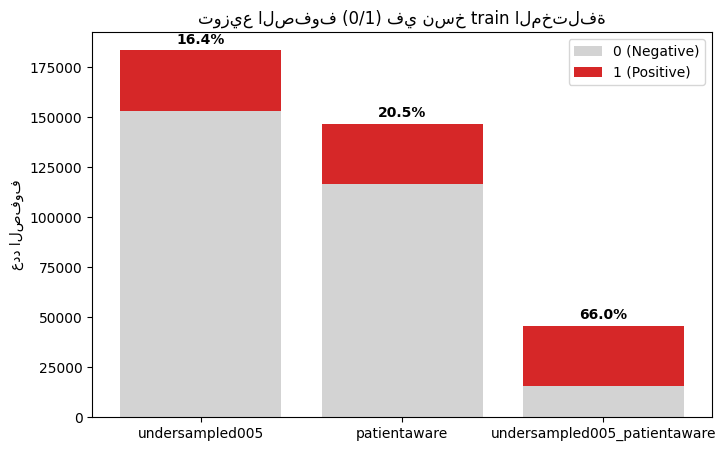

In [10]:
import matplotlib.pyplot as plt

# البيانات من الفايلات الثلاثة
datasets = [
    ("undersampled005", 183494, 30178, 153316, 0.1645),
    ("patientaware", 146834, 30178, 116656, 0.2055),
    ("undersampled005_patientaware", 45717, 30178, 15539, 0.6601),
]

labels    = [d[0] for d in datasets]
positives = [d[2] for d in datasets]
negatives = [d[3] for d in datasets]

# bar chart stacked
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(labels, negatives, label="0 (Negative)", color="lightgray")
ax.bar(labels, positives, bottom=negatives, label="1 (Positive)", color="tab:red")

ax.set_ylabel("عدد الصفوف")
ax.set_title("توزيع الصفوف (0/1) في نسخ train المختلفة")
ax.legend()

# إضافة النسب فوق الأعمدة
for i, d in enumerate(datasets):
    ax.text(i, d[1]+2000, f"{d[4]*100:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

plt.show()


In [11]:
import pandas as pd
from pathlib import Path

DATA_DIR   = Path("data/processed/splits_by_patient")
ID_COL     = "new_id"
TIME_COL   = "seconds_since_birth"
LABEL_COL  = "y_forecast_24h"
TARGET_POS = 0.20  # ~20% إيجابيات

def make_balanced20(src_name: str, dst_suffix="_balanced20.csv"):
    src = DATA_DIR / src_name
    df  = pd.read_csv(src).sort_values([ID_COL, TIME_COL]).reset_index(drop=True)

    def undersample_patient(g: pd.DataFrame, target_pos_rate=TARGET_POS):
        # نحافظ على كل الإيجابيات
        pos = g[g[LABEL_COL] == 1]
        neg = g[g[LABEL_COL] == 0]

        if len(pos) == 0:
            # مريض غير مصاب: ناخذ نسبة صغيرة ثابتة من السوالب (5%)
            return neg.sample(frac=0.05, random_state=42)

        # مريض مصاب: اضبط عدد السوالب بحيث الإيجابيات ~ target_pos_rate
        desired_total = int(len(pos) / target_pos_rate)  # total ≈ pos / 0.20
        desired_neg   = max(desired_total - len(pos), 0)

        if desired_neg >= len(neg):
            neg_sample = neg
        else:
            neg_sample = neg.sample(n=desired_neg, random_state=42)

        out = pd.concat([pos, neg_sample], axis=0)
        return out

    out = (
        df.groupby(ID_COL, group_keys=False)
          .apply(undersample_patient)
          .sort_values([ID_COL, TIME_COL])
          .reset_index(drop=True)
    )

    dst = DATA_DIR / src_name.replace(".csv", dst_suffix)
    out.to_csv(dst, index=False)

    # تقارير سريعة
    def dist(series):
        vc = series.value_counts()
        pr = series.value_counts(normalize=True)
        return f"0: {vc.get(0,0):,} ({pr.get(0,0):.2%}) | 1: {vc.get(1,0):,} ({pr.get(1,0):.2%})"

    print(f"✔ {src.name} → {dst.name} | shape={out.shape}")
    print("قبل :", dist(df[LABEL_COL]))
    print("بعد :", dist(out[LABEL_COL]))
    print("عدد المرضى قبل/بعد:", df[ID_COL].nunique(), "/", out[ID_COL].nunique())
    print("-"*60)

# توليد نسخ الـ 20% لكل من VAL و TEST (الأصلية تبقى كما هي)
make_balanced20("val_forecast24.csv")
make_balanced20("test_forecast24.csv")


C:\Users\96277\AppData\Local\Temp\ipykernel_12144\4232460136.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(undersample_patient)


✔ val_forecast24.csv → val_forecast24_balanced20.csv | shape=(51082, 18)
قبل : 0: 764,192 (99.25%) | 1: 5,787 (0.75%)
بعد : 0: 45,295 (88.67%) | 1: 5,787 (11.33%)
عدد المرضى قبل/بعد: 66 / 65
------------------------------------------------------------


C:\Users\96277\AppData\Local\Temp\ipykernel_12144\4232460136.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(undersample_patient)


✔ test_forecast24.csv → test_forecast24_balanced20.csv | shape=(53029, 18)
قبل : 0: 609,323 (98.75%) | 1: 7,682 (1.25%)
بعد : 0: 45,347 (85.51%) | 1: 7,682 (14.49%)
عدد المرضى قبل/بعد: 66 / 66
------------------------------------------------------------


In [12]:
# ============== Build 24h Sequences (T=144 @10min) + Standardization ==============
from pathlib import Path
import json, numpy as np, pandas as pd

# ---------------- Paths & Config ----------------
DATA_DIR = Path("data/processed/splits_by_patient").resolve()
OUT_DIR  = Path("data/processed/seq24").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL     = "new_id"
TIME_COL   = "seconds_since_birth"
LABEL_COL  = "y_forecast_24h"
T          = 144            # 24h window (10-min steps)
TRAIN_FILE = DATA_DIR / "train_forecast24_patientaware.csv"

VAL_FILE_ORIG   = DATA_DIR / "val_forecast24.csv"
TEST_FILE_ORIG  = DATA_DIR / "test_forecast24.csv"
VAL_FILE_BAL20  = DATA_DIR / "val_forecast24_balanced20.csv"
TEST_FILE_BAL20 = DATA_DIR / "test_forecast24_balanced20.csv"

# ---------------- Helpers ----------------
def detect_features(df: pd.DataFrame):
    """اختر كل الأعمدة الرقمية ما عدا ID/TIME/LABEL (+ sepsis_window إن وجد)."""
    drop = {ID_COL, TIME_COL, LABEL_COL, "sepsis_window"}
    num_cols = df.select_dtypes(include=["number"]).columns
    feats = [c for c in num_cols if c not in drop]
    if len(feats) == 0:
        raise ValueError("ما في أعمدة Features رقمية بعد الاستثناءات.")
    return feats

def fit_standardizer(train_df: pd.DataFrame, feats):
    mean = train_df[feats].mean().astype("float32")
    std  = train_df[feats].std(ddof=0).replace(0, 1.0).astype("float32")
    return mean, std

def apply_standardizer(df: pd.DataFrame, feats, mean, std):
    df2 = df.copy()
    df2[feats] = (df2[feats] - mean) / std
    return df2

def build_sequences_from_df(df: pd.DataFrame, feats, split_name: str, T=144):
    """
    - train: stride=36 (≈6 ساعات)
    - غير ذلك: stride=T (بدون تداخل)
    - label = قيمة LABEL_COL عند نهاية النافذة
    """
    stride = 36 if split_name == "train" else T

    X_list, y_list, pid_list = [], [], []
    for pid, g in df.groupby(ID_COL, sort=False):
        g = g.sort_values(TIME_COL)
        arr = g[feats].to_numpy(np.float32)
        y   = g[LABEL_COL].to_numpy(np.int64)
        n   = len(arr)
        if n < T:
            continue
        for s in range(0, n - T + 1, stride):
            e = s + T
            X_list.append(arr[s:e])
            y_list.append(int(y[e-1]))     # ليبل آخر النقطة
            pid_list.append(int(pid))
    if len(X_list) == 0:
        return (np.empty((0, T, len(feats)), dtype=np.float32),
                np.empty((0,), dtype=np.int64),
                np.empty((0,), dtype=np.int64))
    return np.stack(X_list), np.array(y_list), np.array(pid_list)

def save_seq(split_tag: str, X, y, pids):
    np.save(OUT_DIR / f"X_{split_tag}.npy",   X)
    np.save(OUT_DIR / f"y_{split_tag}.npy",   y)
    np.save(OUT_DIR / f"pid_{split_tag}.npy", pids)
    print(f"✔ {split_tag}: X={X.shape} | y={y.shape} | pos_rate={y.mean():.4f}")

# ---------------- 1) Fit scaler on TRAIN(20%) ----------------
assert TRAIN_FILE.exists(), f"Missing: {TRAIN_FILE}"
train_df_raw = pd.read_csv(TRAIN_FILE).sort_values([ID_COL, TIME_COL]).reset_index(drop=True)
FEATURES = detect_features(train_df_raw)
mu, sigma = fit_standardizer(train_df_raw, FEATURES)

# save scaler
scaler_path = OUT_DIR / "scaler_train20.json"
scaler_path.write_text(json.dumps({"features": FEATURES,
                                   "mean": {k: float(mu[k]) for k in FEATURES},
                                   "std":  {k: float(sigma[k]) for k in FEATURES}},
                                  ensure_ascii=False, indent=2))
print(f"✔ Saved scaler to {scaler_path}")

# ---------------- 2) Build TRAIN sequences ----------------
train_df = apply_standardizer(train_df_raw, FEATURES, mu, sigma)
Xt, yt, pt = build_sequences_from_df(train_df, FEATURES, split_name="train", T=T)
save_seq("train24", Xt, yt, pt)

# ---------------- 3) Build VAL/TEST (original + balanced20 if exist) --------------
eval_sets = []
if VAL_FILE_ORIG.exists():   eval_sets.append(("val24",   pd.read_csv(VAL_FILE_ORIG)))
if TEST_FILE_ORIG.exists():  eval_sets.append(("test24",  pd.read_csv(TEST_FILE_ORIG)))
if VAL_FILE_BAL20.exists():  eval_sets.append(("val24_bal20",  pd.read_csv(VAL_FILE_BAL20)))
if TEST_FILE_BAL20.exists(): eval_sets.append(("test24_bal20", pd.read_csv(TEST_FILE_BAL20)))

for tag, df_raw in eval_sets:
    df_raw = df_raw.sort_values([ID_COL, TIME_COL]).reset_index(drop=True)
    # تأكد من نفس الأعمدة
    missing = [c for c in FEATURES if c not in df_raw.columns]
    if missing:
        raise ValueError(f"{tag}: ميزات ناقصة بالمقارنة مع TRAIN: {missing}")

    df_std = apply_standardizer(df_raw, FEATURES, mu, sigma)
    X, y, p = build_sequences_from_df(df_std, FEATURES, split_name=tag.split("24")[0], T=T)
    save_seq(tag, X, y, p)


✔ Saved scaler to C:\Users\96277\nicu-sepsis\data\processed\seq24\scaler_train20.json
✔ train24: X=(3048, 144, 14) | y=(3048,) | pos_rate=0.2316
✔ val24: X=(5315, 144, 14) | y=(5315,) | pos_rate=0.0073
✔ test24: X=(4250, 144, 14) | y=(4250,) | pos_rate=0.0125
✔ val24_bal20: X=(316, 144, 14) | y=(316,) | pos_rate=0.1234
✔ test24_bal20: X=(326, 144, 14) | y=(326,) | pos_rate=0.1626


In [13]:
from pathlib import Path

SEQ_DIR = Path("data/processed/seq24")

for f in SEQ_DIR.glob("*.dat"):
    try:
        f.unlink()
        print("🗑️ Deleted:", f.name)
    except PermissionError:
        print("⚠️ Skipped (مفتوح ببرنامج):", f.name)

print("\n📂 الملفات المتبقية:")
for f in sorted(SEQ_DIR.glob("*")):
    print(f.name)



📂 الملفات المتبقية:
pid_test24.npy
pid_test24_bal20.npy
pid_train24.npy
pid_val24.npy
pid_val24_bal20.npy
scaler_train20.json
X_test24.npy
X_test24_bal20.npy
X_train24.npy
X_val24.npy
X_val24_bal20.npy
y_test24.npy
y_test24_bal20.npy
y_train24.npy
y_val24.npy
y_val24_bal20.npy


In [14]:
import numpy as np
from pathlib import Path

SEQ_DIR = Path("data/processed/seq24")

splits = ["train24", "val24", "test24", "val24_bal20", "test24_bal20"]

for split in splits:
    try:
        X = np.load(SEQ_DIR / f"X_{split}.npy", mmap_mode="r")
        y = np.load(SEQ_DIR / f"y_{split}.npy", mmap_mode="r")
        p = np.load(SEQ_DIR / f"pid_{split}.npy", mmap_mode="r")
        print(f"{split}: X={len(X)}, y={len(y)}, pid={len(p)}")
    except FileNotFoundError:
        print(f"{split}: ⚠️ الملفات مش موجودة")


train24: X=3048, y=3048, pid=3048
val24: X=5315, y=5315, pid=5315
test24: X=4250, y=4250, pid=4250
val24_bal20: X=316, y=316, pid=316
test24_bal20: X=326, y=326, pid=326


In [15]:
import torch
import torch.nn as nn

# 1) اختيار الجهاز
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2) حساب pos_weight (مثال: 3.32)
pos_weight = torch.tensor([3.32], dtype=torch.float32, device=device)

# 3) تعريف الخسارة
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


Using device: cuda


In [17]:
import torch
print(torch.version.cuda)          # لازم يطلع "11.8"
print(torch.cuda.is_available())   # لازم يطلع True
print(torch.cuda.get_device_name(0))  # لازم يطلع "GeForce GTX 1650"


11.8
True
NVIDIA GeForce GTX 1650


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [19]:
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# 1) اختيار الجهاز
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2) حمّل y_train24 واحسب pos_weight
y_path = Path("data/processed/seq24/y_train24.npy")
y = np.load(y_path)                     # شكلها (N,)
pos = int((y == 1).sum())
neg = int((y == 0).sum())
N   = len(y)
pos_rate = pos / N if N else 0.0
pos_weight_val = (neg / pos) if pos > 0 else 1.0

print(f"Total={N:,} | pos={pos:,} | neg={neg:,} | pos_rate={pos_rate:.4f}")
print(f"pos_weight = neg/pos = {pos_weight_val:.4f}")

# 3) عرّف الـ loss على نفس الجهاز
pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32, device=device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# مثال استخدام داخل التدريب:
# logits: torch.FloatTensor (B, 1) أو (B,)
# targets: torch.FloatTensor (B, 1) أو (B,) بقيم 0/1
# loss = criterion(logits.squeeze(-1), targets.float().to(device))


Using device: cuda
Total=3,048 | pos=706 | neg=2,342 | pos_rate=0.2316
pos_weight = neg/pos = 3.3173


In [20]:
import pandas as pd
df = pd.read_csv("data/processed/splits_by_patient/train_forecast24_patientaware.csv")
print("train rows:", len(df))
print(df["y_forecast_24h"].value_counts(normalize=True))


train rows: 146834
y_forecast_24h
0    0.794475
1    0.205525
Name: proportion, dtype: float64


In [21]:
import numpy as np, pathlib as p
d = p.Path("data/processed/seq24")
for split in ["train24","val24","test24","val24_bal20","test24_bal20"]:
    X = np.load(d/f"X_{split}.npy", mmap_mode="r")
    y = np.load(d/f"y_{split}.npy", mmap_mode="r")
    print(split, "→ X:", X.shape, "| y:", y.shape, "| pos_rate:", float(y.mean()))


train24 → X: (3048, 144, 14) | y: (3048,) | pos_rate: 0.2316272965879265
val24 → X: (5315, 144, 14) | y: (5315,) | pos_rate: 0.007337723424270932
test24 → X: (4250, 144, 14) | y: (4250,) | pos_rate: 0.012470588235294117
val24_bal20 → X: (316, 144, 14) | y: (316,) | pos_rate: 0.12341772151898735
test24_bal20 → X: (326, 144, 14) | y: (326,) | pos_rate: 0.16257668711656442


In [22]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/processed/splits_by_patient")

# الملفات الأساسية
train_file = DATA_DIR / "train_forecast24_patientaware.csv"
val_file   = DATA_DIR / "val_forecast24.csv"
test_file  = DATA_DIR / "test_forecast24.csv"

# اقرأ كل ملف وخذ IDs المرضى
train_ids = pd.read_csv(train_file)["new_id"].unique()
val_ids   = pd.read_csv(val_file)["new_id"].unique()
test_ids  = pd.read_csv(test_file)["new_id"].unique()

# إجمالي عدد المرضى
total = len(set(train_ids) | set(val_ids) | set(test_ids))

print(f"🧾 Patients per split:")
print(f"Train: {len(train_ids)} ({len(train_ids)/total:.2%})")
print(f"Val  : {len(val_ids)} ({len(val_ids)/total:.2%})")
print(f"Test : {len(test_ids)} ({len(test_ids)/total:.2%})")
print(f"Total: {total}")

# تأكيد إنه ما في أي تداخل
overlap_train_val  = set(train_ids) & set(val_ids)
overlap_train_test = set(train_ids) & set(test_ids)
overlap_val_test   = set(val_ids) & set(test_ids)

print("\nOverlap check:")
print("Train ∩ Val :", len(overlap_train_val))
print("Train ∩ Test:", len(overlap_train_test))
print("Val ∩ Test  :", len(overlap_val_test))


🧾 Patients per split:
Train: 306 (69.86%)
Val  : 66 (15.07%)
Test : 66 (15.07%)
Total: 438

Overlap check:
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


In [1]:
import pandas as pd

# مسار الملف
fpath = "data/processed/splits_by_patient/train_forecast24_undersampled005.csv"

# اقرأ أول 5 صفوف مع أسماء الأعمدة
df = pd.read_csv(fpath)
print("عدد الصفوف:", len(df))
print("عدد الأعمدة:", len(df.columns))
print("\n📋 أسماء الأعمدة:")
print(df.columns.tolist())

# كمان نطبع أول 3 صفوف للمعاينة
print("\nأول 3 صفوف:")
print(df.head(3))


عدد الصفوف: 183494
عدد الأعمدة: 18

📋 أسماء الأعمدة:
['new_id', 'seconds_since_birth', 'mean_hr', 'mean_spo2', 'sd_hr', 'sd_spo2', 'skewness_hr', 'skewness_spo2', 'kurtosis_hr', 'kurtosis_spo2', 'max_xc_hr_spo2', 'min_xc_hr_spo2', 'sub', 'sepsis_window', 'blackout_window', 'sex', 'birth_weight', 'y_forecast_24h']

أول 3 صفوف:
   new_id  seconds_since_birth     mean_hr  mean_spo2      sd_hr   sd_spo2  \
0   74399              4036620  182.762712  99.130000  11.064343  1.655971   
1   74399              4040220  160.190000  99.763333   7.743412  0.669939   
2   74399              4042020  158.893333  98.683333  10.448566  3.839992   

   skewness_hr  skewness_spo2  kurtosis_hr  kurtosis_spo2  max_xc_hr_spo2  \
0    -0.272404      -3.115738     2.959631      14.232334        0.404743   
1     0.632885      -3.562459     3.772393      17.895792        0.253995   
2    -1.727692      -3.502019    11.314256      16.072992        0.139075   

   min_xc_hr_spo2  sub  sepsis_window  blackout_wi